# DISTRIBUIÇÃO NORMAL

A distribuição normal foi descrita pela primeira vez por Abraham de Moivre em 1733, ao estudar jogos de azar e aproximar a distribuição binomial para um número grande de tentativas. Mais tarde, Carl Friedrich Gauss desenvolveu a função de forma independente, relacionando-a a erros de medição em observações astronômicas — por isso ela também é chamada de **distribuição gaussiana**.

## Propriedades

**Simetria** — a curva é perfeitamente simétrica em torno da média $\mu$: a metade esquerda é um espelho da direita.

$$
f(\mu + z) = f(\mu - z)
$$

**Curva em forma de sino** — a maior concentração de dados fica perto da média, e vai rareando conforme se afasta dela (pra qualquer lado). A função de densidade de probabilidade (FDP) é:

$$
f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

onde $\mu$ é a média (centro da distribuição) e $\sigma$ é o desvio padrão (dispersão dos dados).

**Assintótica** — as caudas se aproximam do eixo horizontal, mas nunca o tocam:

$$
\lim_{x \to \pm\infty} f(x) = 0
$$

**Área sob a curva** — a área total sob a curva é sempre igual a 1 (100%):

$$
\int_{-\infty}^{\infty} f(x)\,dx = 1
$$

**Notação** — se uma variável aleatória $X$ segue uma distribuição normal com média $\mu$ e desvio padrão $\sigma$, escrevemos $X \sim N(\mu, \sigma)$ (ou $X \sim N(\mu, \sigma^2)$ quando a notação usa a variância).

**Esperança e variância**:

$$
E(X) = \mu \qquad \text{Var}(X) = \sigma^2
$$

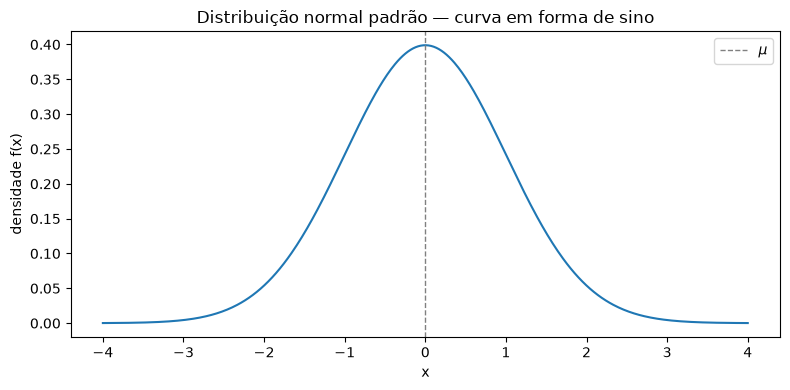

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

mu, sigma = 0, 1
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
y = norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color="tab:blue")
ax.axvline(mu, color="gray", linestyle="--", linewidth=1, label=r"$\mu$")
ax.set_title("Distribuição normal padrão — curva em forma de sino")
ax.set_xlabel("x")
ax.set_ylabel("densidade f(x)")
ax.legend()
plt.tight_layout()
plt.show()

## Regra 68-95-99,7 (regra empírica)

Na curva normal, a área sob a curva entre:

- $\mu \pm 1\sigma$ contém **≈ 68%** dos dados
- $\mu \pm 2\sigma$ contém **≈ 95%** dos dados
- $\mu \pm 3\sigma$ contém **≈ 99,7%** dos dados

A distribuição normal também é **mesocúrtica**: suas caudas não são nem mais pesadas nem mais leves que o "normal" — é a curva de referência para comparar a curtose de outras distribuições.

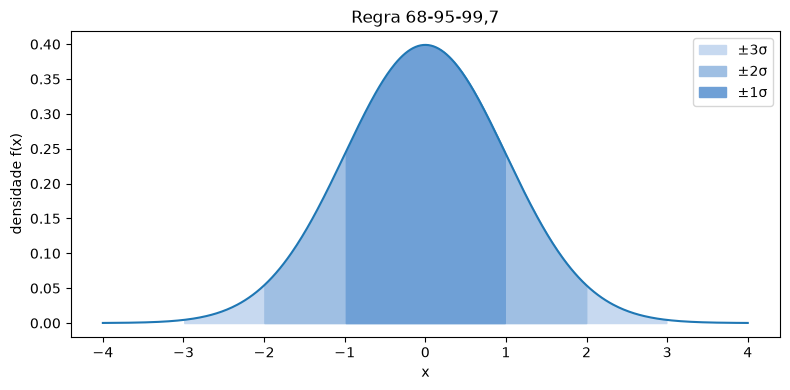

±1σ contém 68.3% dos dados
±2σ contém 95.4% dos dados
±3σ contém 99.7% dos dados


In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color="tab:blue")

cores = ["#c7d9f0", "#9fbfe3", "#6fa0d6"]
for k, cor in zip([3, 2, 1], cores, strict=True):
    faixa = (x >= mu - k * sigma) & (x <= mu + k * sigma)
    ax.fill_between(x, y, where=faixa, color=cor, label=f"±{k}σ")

ax.set_title("Regra 68-95-99,7")
ax.set_xlabel("x")
ax.set_ylabel("densidade f(x)")
ax.legend()
plt.tight_layout()
plt.show()

for k in [1, 2, 3]:
    area = norm.cdf(mu + k * sigma, mu, sigma) - norm.cdf(mu - k * sigma, mu, sigma)
    print(f"±{k}σ contém {area:.1%} dos dados")

## Exemplo prático — distribuição computacional

Suponha que o salário dos funcionários de uma empresa siga uma distribuição normal com média $\mu = 2500$ e desvio padrão $\sigma = 170$: $\text{salário} \sim N(2500,\ 170)$.

### Pergunta 1: qual a probabilidade de sortear um funcionário com salário entre 2.400 e 2.600?

Usamos a **função de distribuição acumulada (CDF)**, que dá $P(X \leq x)$. Para um intervalo, calculamos a CDF do limite superior e subtraímos a CDF do limite inferior:

$$
P(a \leq X \leq b) = \Phi\left(\frac{b - \mu}{\sigma}\right) - \Phi\left(\frac{a - \mu}{\sigma}\right)
$$

**O que é cada símbolo:**

| Símbolo | Significado |
|---|---|
| $\Phi$ (phi maiúsculo) | CDF da normal **padrão** $N(0,1)$: $\Phi(z) = P(Z \leq z)$. É a área acumulada sob a curva até $z$. |
| $\varphi$ (phi minúsculo) | Densidade (PDF) da normal padrão — a altura da curva em cada ponto, **não** é probabilidade. É a mesma fórmula $f(x)$ da seção **Propriedades** (acima), só com $\mu=0,\ \sigma=1$. |
| $a$ | limite **inferior** do intervalo (aqui, 2.400) |
| $b$ | limite **superior** do intervalo (aqui, 2.600) |
| $\dfrac{x - \mu}{\sigma}$ | o **z-score**: padroniza $x$ pra escala da normal padrão antes de aplicar $\Phi$ |

Ou seja: $\Phi\left(\frac{b-\mu}{\sigma}\right)$ dá $P(X \leq b)$, $\Phi\left(\frac{a-\mu}{\sigma}\right)$ dá $P(X \leq a)$, e a diferença entre as duas sobra só a fatia do meio — a probabilidade do intervalo $[a, b]$.

$\Phi$ e $\varphi$ se relacionam assim: $\Phi$ é a **integral** (área acumulada) de $\varphi$, e $\varphi$ é a **derivada** de $\Phi$:

$$
\Phi(z) = \int_{-\infty}^{z} \varphi(t)\,dt \qquad \varphi(z) = \frac{d}{dz}\Phi(z)
$$

No `scipy`, `norm.cdf(x, media, scale=desvio)` já calcula $\Phi\left(\frac{x-\mu}{\sigma}\right)$ direto — a padronização (z-score) acontece por dentro da função, não precisa fazer na mão.

In [3]:
from distribuicao_normal import probabilidade_entre

media, desvio = 2500, 170
p = probabilidade_entre(2400, 2600, media, desvio)
print(f"P(2400 ≤ salário ≤ 2600) = {p:.4f} ({p:.2%})")

P(2400 ≤ salário ≤ 2600) = 0.4436 (44.36%)


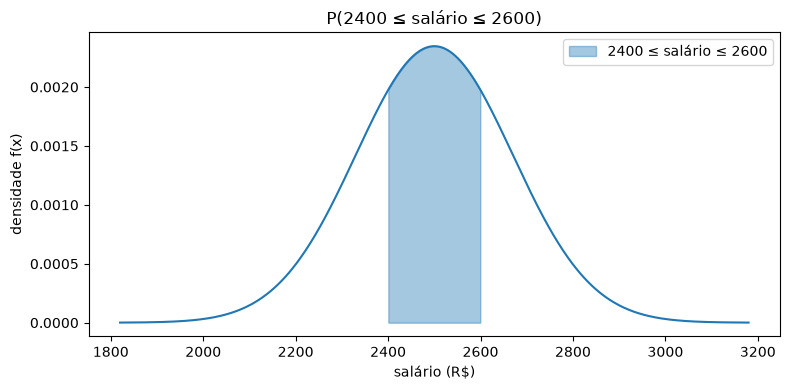

In [4]:
x_sal = np.linspace(media - 4 * desvio, media + 4 * desvio, 500)
y_sal = norm.pdf(x_sal, media, desvio)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_sal, y_sal, color="tab:blue")
faixa = (x_sal >= 2400) & (x_sal <= 2600)
ax.fill_between(
    x_sal, y_sal, where=faixa, color="tab:blue", alpha=0.4, label="2400 ≤ salário ≤ 2600"
)
ax.set_title("P(2400 ≤ salário ≤ 2600)")
ax.set_xlabel("salário (R$)")
ax.set_ylabel("densidade f(x)")
ax.legend()
plt.tight_layout()
plt.show()

## Calculando à mão (sem scipy)

Vale a pena refazer o cálculo de $P(2400 \leq \text{salário} \leq 2600)$ na mão pelo menos uma vez, com **z-score + tabela-Z**, do jeito que se fazia antes de existir Python — ajuda a entender o que o `scipy` está fazendo por baixo dos panos.

### Passo 1 — Padronizar os dois limites (z-score)

Antes de consultar qualquer tabela, cada salário precisa virar um **z-score**: quantos desvios padrão ele está distante da média.

$$
z = \frac{x - \mu}{\sigma}
$$

$$
z_b = \frac{2600 - 2500}{170} = \frac{100}{170} \approx 0{,}588 \qquad z_a = \frac{2400 - 2500}{170} = \frac{-100}{170} \approx -0{,}588
$$

Tabelas impressas costumam ter só 2 casas decimais — arredondamos $0{,}588 \to 0{,}59$ pra poder consultar.

### Passo 2 — Consultar Φ(0,59) na tabela-Z

Não existe fórmula simples pra calcular a área embaixo da curva normal — é uma integral sem solução algébrica. Décadas atrás, alguém já calculou essa área pra cada z possível, uma vez só, e publicou o resultado numa tabela pronta. É nela que vamos **consultar** o valor, não calcular.

Cada célula da tabela é uma probabilidade: $\Phi(z) = P(Z \leq z)$, a área acumulada à esquerda daquele z. **O que queremos achar:** só o número $\Phi(0{,}59)$, que vamos usar na subtração do passo 4.

**Como ler:** quebre o z em duas partes — a 1ª casa decimal é a **linha**, a 2ª casa decimal é a **coluna**. Pra $z=0{,}59$: linha `0,5` + coluna `0,09` → o cruzamento das duas é a resposta.

| z | ,00 | ,01 | ,02 | ,03 | ,04 | ,05 | ,06 | ,07 | ,08 | **,09** |
|---|---|---|---|---|---|---|---|---|---|---|
| 0,3 | 0,6179 | 0,6217 | 0,6255 | 0,6293 | 0,6331 | 0,6368 | 0,6406 | 0,6443 | 0,6480 | 0,6517 |
| 0,4 | 0,6554 | 0,6591 | 0,6628 | 0,6664 | 0,6700 | 0,6736 | 0,6772 | 0,6808 | 0,6844 | 0,6879 |
| **0,5** | 0,6915 | 0,6950 | 0,6985 | 0,7019 | 0,7054 | 0,7088 | 0,7123 | 0,7157 | 0,7190 | **0,7224** |
| 0,6 | 0,7257 | 0,7291 | 0,7324 | 0,7357 | 0,7389 | 0,7422 | 0,7454 | 0,7486 | 0,7517 | 0,7549 |
| 0,7 | 0,7580 | 0,7611 | 0,7642 | 0,7673 | 0,7704 | 0,7734 | 0,7764 | 0,7794 | 0,7823 | 0,7852 |

Então $\Phi(0{,}59) \approx 0{,}7224$.

### Passo 3 — Usar simetria para o z negativo

Tabelas-Z padrão só listam z positivo. Para z negativo, a simetria da curva resolve:

$$
\Phi(-z) = 1 - \Phi(z) \qquad \Phi(-0{,}59) = 1 - 0{,}7224 = 0{,}2776
$$

### Passo 4 — Subtrair as duas áreas

A área acumulada até $b$, menos a área acumulada até $a$, sobra só a fatia do meio — exatamente o intervalo que queremos.

$$
P(a \leq X \leq b) = \Phi(z_b) - \Phi(z_a) = 0{,}7224 - 0{,}2776 = 0{,}4448 \ (44{,}48\%)
$$

In [5]:
from math import erf, sqrt


def Phi(z):
    # CDF da normal padrão via erf — a mesma matemática por trás de scipy.stats.norm.cdf
    return 0.5 * (1 + erf(z / sqrt(2)))


a, b = 2400, 2600
z_a = (a - media) / desvio
z_b = (b - media) / desvio

# à mão: z arredondado pra 2 casas, como numa tabela impressa
z_a_tab, z_b_tab = round(z_a, 2), round(z_b, 2)
p_mao = Phi(z_b_tab) - Phi(z_a_tab)
print(f"à mão:  Φ({z_b_tab}) - Φ({z_a_tab}) = {p_mao:.4f} ({p_mao:.2%})")

# exato: sem arredondar o z (é isso que o scipy faz)
p_exato = Phi(z_b) - Phi(z_a)
print(f"exato:  Φ({z_b:.4f}) - Φ({z_a:.4f}) = {p_exato:.4f} ({p_exato:.2%})")

à mão:  Φ(0.59) - Φ(-0.59) = 0.4448 (44.48%)
exato:  Φ(0.5882) - Φ(-0.5882) = 0.4436 (44.36%)


**Por que a diferença (44,48% vs. 44,36%)?** $100/170 = 0{,}58823...$ — a tabela só tem 2 casas decimais, então arredondamos pra $0{,}59$ antes de consultar. O cálculo exato (e o `scipy`) usa o z completo, sem arredondar. Refazendo com o z completo, os dois batem em 44,36%, igual ao resultado do `probabilidade_entre` lá em cima.

### Pergunta 2: qual a probabilidade de o salário ser maior que 2.600?

Como a CDF dá $P(X \leq x)$, para a cauda direita usamos o espaço complementar:

$$
P(X > 2600) = 1 - \Phi\left(\frac{2600 - \mu}{\sigma}\right)
$$

In [6]:
from distribuicao_normal import probabilidade_acima

p_acima = probabilidade_acima(2600, media, desvio)
print(f"P(salário > 2600) = {p_acima:.4f} ({p_acima:.2%})")

P(salário > 2600) = 0.2782 (27.82%)


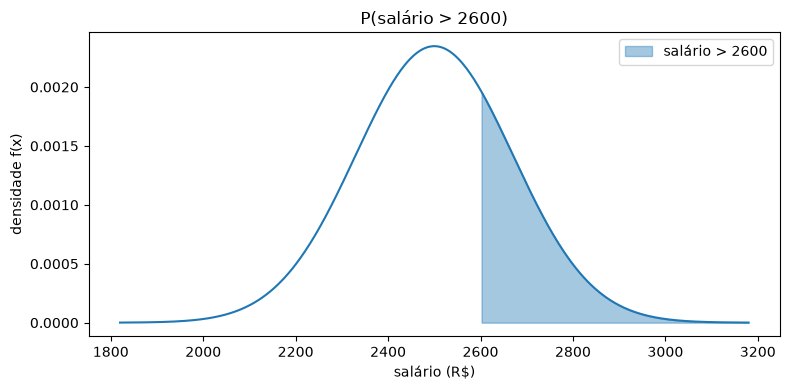

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_sal, y_sal, color="tab:blue")
faixa = x_sal > 2600
ax.fill_between(x_sal, y_sal, where=faixa, color="tab:blue", alpha=0.4, label="salário > 2600")
ax.set_title("P(salário > 2600)")
ax.set_xlabel("salário (R$)")
ax.set_ylabel("densidade f(x)")
ax.legend()
plt.tight_layout()
plt.show()

## Notas

- Como o salário é uma variável **contínua**, $P(X = x)$ é sempre zero — só faz sentido falar em probabilidade de a variável cair dentro de um intervalo.
- As funções `probabilidade_abaixo`, `probabilidade_acima` e `probabilidade_entre` (em `distribuicao_normal.py`) encapsulam o padrão `scipy.stats.norm.cdf` usado nos dois exemplos.

**Próximos passos:** o livro segue para distribuição Gama e Exponencial — ainda não estudadas pelo grupo.